In [1]:
import json
import string
import random
import nltk
import numpy as num
from nltk.stem import WordNetLemmatizer # It has the ability to lemmatize.
import tensorflow as tensorF # A multidimensional array of elements is represented by this symbol.
from tensorflow.keras import Sequential # Sequential groups a linear stack of layers into a tf.keras.Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM

nltk.download("punkt")# required package for tokenization
nltk.download("wordnet")# word database

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mayuk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mayuk\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
#3 Loading the Dataset: intents.json
data_file = open('Data.json').read()
data = json.loads(data_file)

data

{'ourIntents': [{'tag': 'age',
   'patterns': ['how old are you?'],
   'responses': ['I am 22 years old and my birthday is on 17th January']},
  {'tag': 'greeting',
   'patterns': ['hi', 'hello', 'hey', 'heyy'],
   'responses': ['Hi there', 'Hello', 'Hi :)']},
  {'tag': 'goodbye',
   'patterns': ['bye', 'later'],
   'responses': ['Bye', 'take care']},
  {'tag': 'name',
   'patterns': ["what's your name?", 'who are you?'],
   'responses': ['I am Tanjiro']},
  {'tag': 'polite',
   'patterns': ['hi there',
    'how are you',
    'is anyone there',
    'hola',
    'good day',
    'namaste',
    'yo'],
   'responses': ['Hello',
    'Good to see you again',
    'Hi there, how can I help?']},
  {'tag': 'goodbye',
   'patterns': ['bye',
    'see you later',
    'goodbye',
    'get lost',
    'till next time',
    'bye'],
   'responses': ['See you!', 'Have a nice day', 'Bye! Come back again soon.'],
   'context': ['']},
  {'tag': 'thanks',
   'patterns': ['thanks',
    'thank you',
    "that's 

### Processing data

In [3]:
lm = WordNetLemmatizer() #reducing words to their base or dictionary form

ourClasses = []
newWords = []
documentX = []
documentY = []
# Each intent is tokenized into words and the patterns and their associated tags are added to their respective lists.
for intent in data["ourIntents"]:
    for pattern in intent["patterns"]:
        ournewTkns = nltk.word_tokenize(pattern)
        newWords.extend(ournewTkns)
        documentX.append(pattern)
        documentY.append(intent['tag'])
    if intent["tag"] not in ourClasses:
        ourClasses.append(intent["tag"])

newWords = [lm.lemmatize(word.lower()) for word in newWords if word not in string.punctuation]
newWords = sorted(set(newWords))
ourClasses = sorted(set(ourClasses))

In [4]:
trainingData  = []
outEmpty = [0] * len(ourClasses)

for idx, doc in enumerate(documentX):
    bag0words = []
    text = lm.lemmatize(doc.lower())
    for word in newWords :
        bag0words.append(1) if word in text else bag0words.append(0)

    outputRow = list(outEmpty)
    outputRow[ourClasses.index(documentY[idx])] = 1 
    trainingData.append([bag0words, outputRow])

random.shuffle(trainingData)
trainingData = num.array(trainingData, dtype=object)

x = num.array(list(trainingData[:,0]))
y = num.array(list(trainingData[:,1]))

#### Defining and training a neural network model 


In [47]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.regularizers import l2

# Define the number of output classes (intent tags)
oShape = len(ourClasses)

# Define the model with Embedding and Bidirectional LSTM
Model = Sequential()

# Add an Embedding layer
Model.add(Embedding(input_dim=len(newWords), output_dim=128, input_shape=(len(x[0]),)))

# Add a Bidirectional LSTM layer with 128 units
Model.add(Bidirectional(LSTM(128, return_sequences=True)))
Model.add(BatchNormalization())
Model.add(Dropout(0.5))

# Add another Bidirectional LSTM layer with 64 units
Model.add(Bidirectional(LSTM(64)))
Model.add(BatchNormalization())
Model.add(Dropout(0.3))

# Add a Dense output layer with softmax activation and L2 regularization
Model.add(Dense(oShape, activation='softmax', kernel_regularizer=l2(0.01)))

# Compile the model with a lower learning rate
md = tensorF.keras.optimizers.Adam(learning_rate=0.0005)
Model.compile(optimizer=md, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
print(Model.summary())   

C:\Users\mayuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:81: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 131, 128)            │          16,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_10 (Bidirectional)     │ (None, 131, 256)            │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 131, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 131, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_11 (Bidirectional)     │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 45)                  │           5,805 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 451,629 (1.72 MB)

 Trainable params: 450,861 (1.72 MB)

 Non-trainable params: 768 (3.00 KB)

None


In [48]:
# Reshape the input data to be 3D (samples, timesteps, features)
x = num.array(x).reshape((x.shape[0], x.shape[1], 1))

#### Building useful features

In [50]:
# Train the model and save the history
history = Model.fit(x, y, epochs=250, verbose=1)

# Get the list of accuracy values from the history
accuracy_values = history.history['accuracy']

# Calculate the average accuracy
average_accuracy = sum(accuracy_values) / len(accuracy_values)

print(f"accuracy: {average_accuracy:.4f}")


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9555 - loss: 0.3076
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9633 - loss: 0.2538
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9803 - loss: 0.2517
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9620 - loss: 0.2828
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9606 - loss: 0.2848
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9738 - loss: 0.2265
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8979 - loss: 0.3634
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9528 - loss: 0.3085
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8913 - loss: 0.3509
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9007 - loss: 0.3345
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9229 - loss: 0.3028
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy:

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

# Split data into train and test sets (80-20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train model with validation on test set
history = Model.fit(x_train, y_train, 
                    epochs=250, 
                    validation_data=(x_test, y_test),
                    verbose=1)

# Predictions
y_pred = Model.predict(x_test)
y_pred_classes = num.argmax(y_pred, axis=1)
y_true_classes = num.argmax(y_test, axis=1) 


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.9529 - loss: 0.1901 - val_accuracy: 0.9474 - val_loss: 0.1759
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9829 - loss: 0.1509 - val_accuracy: 0.9474 - val_loss: 0.2027
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9502 - loss: 0.1786 - val_accuracy: 0.9474 - val_loss: 0.2395
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9634 - loss: 0.2015 - val_accuracy: 0.8947 - val_loss: 0.3198
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9895 - loss: 0.1502 - val_accuracy: 0.8947 - val_loss: 0.2764
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9659 - loss: 0.1911 - val_accuracy: 0.8947 - val_loss: 0.2641
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 0.1289 - val_accuracy: 0.8947 - val_loss: 0.2861
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9646 - loss: 0.1965 - val_accuracy: 0.8947 - va

In [52]:
len(x_train)

76

In [53]:
len(y_test)

19

In [54]:
Model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7895 - loss: 0.8706


[0.8705755472183228, 0.7894737124443054]

In [55]:
Model.evaluate(x_train,y_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9424 - loss: 0.2263


[0.2047196626663208, 0.9473684430122375]

In [56]:
cm=tensorF.math.confusion_matrix(labels=y_true_classes, predictions=y_pred_classes)
cm

<tf.Tensor: shape=(43, 43), dtype=int32, numpy=
array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]])>

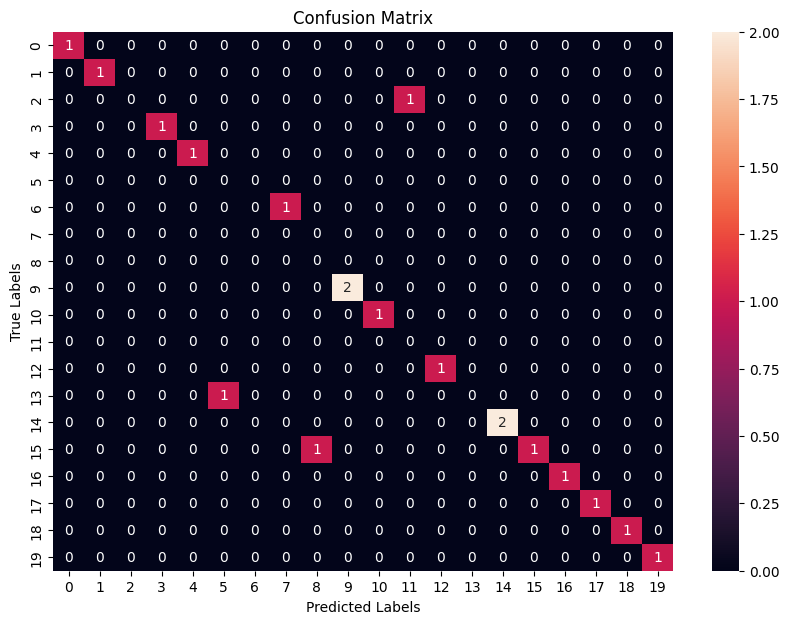

In [57]:
# Confusion Matrix
import seaborn as sns
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [58]:
# 3. Additional Metrics
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Test Accuracy: 0.7895
Precision: 0.8421
Recall: 0.7895
F1 Score: 0.8070


C:\Users\mayuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mayuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
def ourText(text):
  newtkns = nltk.word_tokenize(text)
  newtkns = [lm.lemmatize(word) for word in newtkns]
  return newtkns

def wordBag(text, vocab):
    newtkns = ourText(text)
    bagOwords = [0] * len(vocab)
    for w in newtkns:
        for idx, word in enumerate(vocab):
            if word == w:
                bagOwords[idx] = 1
    return num.array(bagOwords).reshape(1, len(vocab), 1)

def Pclass(text, vocab, labels):
    bagOwords = wordBag(text, vocab)  # Get the bag of words (already reshaped)
    ourResult = Model.predict(bagOwords)[0]  # Predict with the reshaped input
    newThresh = 0.2
    yp = [[idx, res] for idx, res in enumerate(ourResult) if res > newThresh]

    yp.sort(key=lambda x: x[1], reverse=True)
    newList = []
    for r in yp:
        newList.append(labels[r[0]])
    return newList

def getRes(firstlist, fJson):
  tag = firstlist[0]
  listOfIntents = fJson["ourIntents"]
  for i in listOfIntents:
    if i["tag"] == tag:
      ourResult = random.choice(i["responses"])
      break
  return ourResult

In [60]:
pip install googletrans==4.0.0-rc1


Note: you may need to restart the kernel to use updated packages.


In [61]:
pip install pygame

Note: you may need to restart the kernel to use updated packages.


In [62]:
from googletrans import Translator
from gtts import gTTS
import os
import string
from pygame import mixer
import time

# Initialize pygame mixer
mixer.init()

# Initialize the translator
translator = Translator()

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

while True:
    newMessage = input("User: ").lower()
    
    if newMessage.lower() in ["y", "exit", "quit"]:
        print("Goodbye! Have a great day!")
        break
    
    newMessage = remove_punctuation(newMessage)
    translatedMessage = translator.translate(newMessage, src='auto', dest='en').text.lower()
    
    intents = Pclass(translatedMessage, newWords, ourClasses)
    ourResult = getRes(intents, data)
    
    user_lang = translator.detect(newMessage).lang
    translatedResponse = translator.translate(ourResult, src='en', dest=user_lang).text
    
    print("Bot:", translatedResponse)
    
    # Text-to-Speech Conversion
    try:
        tts = gTTS(
            text=translatedResponse,
            lang=user_lang,
            slow=False,
            lang_check=False
        )
        tts.save("bot_response1.mp3")
    
    # Load and play the audio file
        mixer.music.load("bot_response1.mp3")
        mixer.music.play()
    
    # Wait for audio to finish playing
        while mixer.music.get_busy():
            time.sleep(0.1)  # Add small sleep intervals
    
    # Stop and unload the music
        mixer.music.stop()
        mixer.music.unload()
    
    # Cleanup with retry logic
        for _ in range(3):  # Try up to 3 times
            try:
                os.remove("bot_response1.mp3")
                break
            except PermissionError:
                time.sleep(0.1)  # Wait 100ms before retrying
    except Exception as e:
        print(f"Voice assistance error: {str(e)}")
        print("Here's the text response instead:", translatedResponse)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


User:  hi


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Bot: Hi :)


User:  what's your name?


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Bot: Hi there, how can I help?


User:  y


Goodbye! Have a great day!
